<a href="https://colab.research.google.com/github/pavithramalla/Heart_rate/blob/main/Monitoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost tensorflow -q
print(" All packages installed successfully!")

 All packages installed successfully!


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [48]:
from google.colab import files
print("Please upload your Dataset.csv file:")
uploaded = files.upload()
import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f" Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Please upload your Dataset.csv file:


Saving Dataset.csv to Dataset (1).csv
 Dataset loaded: 1,552,210 rows × 44 columns
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


In [75]:
data = pd.read_csv("Dataset.csv")

print(data.shape)
data.head()

(1552210, 44)


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,1,0,17072
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,2,0,17072
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,3,0,17072
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0,NaN,NaN,-0.02,4,0,17072
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0,NaN,NaN,-0.02,5,0,17072


In [77]:
print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")


DATASET LOADED SUCCESSFULLY

Dataset Shape: (1552210, 12)
Total Rows: 1,552,210
Total Columns: 12


In [78]:
print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
print(df.info())

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)


DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552210 entries, 0 to 1552209
Data columns (total 12 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Hour         1552210 non-null  int64  
 1   HR           1552210 non-null  float64
 2   O2Sat        1552210 non-null  float64
 3   Temp         1552210 non-null  float64
 4   SBP          1552210 non-null  float64
 5   MAP          1552210 non-null  float64
 6   DBP          1552210 non-null  float64
 7   Resp         1552210 non-null  float64
 8   Age          1552210 non-null  float64
 9   Gender       1552210 non-null  int64  
 10  ICULOS       1552210 non-null  int64  
 11  SepsisLabel  1552210 non-null  int64  
dtypes: float64(8), int64(4)
memory usage: 142.1 MB
None

FIRST 5 ROWS


In [79]:
columns_to_remove = ['Patient_ID', 'Unit1', 'Unit2', 'HospAdmTime']
columns_to_drop = [col for col in columns_to_remove if col in df.columns]

print("Columns to be removed:", columns_to_drop)
df = df.drop(columns=columns_to_drop)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print(f"\n Removed {len(columns_to_drop)} columns")
print(f"New shape: {df.shape}")

Columns to be removed: []

 Removed 0 columns
New shape: (1552210, 12)


In [80]:
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': missing_data.values,
    'Missing Percentage': missing_percentage.values
})
missing_df = missing_df.sort_values('Missing Percentage', ascending=False)

print("="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)
display(missing_df.head(20))

high_missing_cols = missing_df[missing_df['Missing Percentage'] > 80]['Column'].tolist()
print(f"\n Columns with >80% missing data: {len(high_missing_cols)}")
print(high_missing_cols)

MISSING VALUES ANALYSIS


,Column,Missing Count,Missing Percentage
0,Hour,0,0.0
1,HR,0,0.0
2,O2Sat,0,0.0
3,Temp,0,0.0
4,SBP,0,0.0
5,MAP,0,0.0
6,DBP,0,0.0
7,Resp,0,0.0
8,Age,0,0.0
9,Gender,0,0.0



 Columns with >80% missing data: 0
[]


In [81]:
missing_percent = data.isnull().mean()*100
cols_to_drop = missing_percent[missing_percent > 80].index
data = data.drop(columns=cols_to_drop)
print(cols_to_drop)
data = data.fillna(data.median())

Index(['EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
       'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets'],
      dtype='object')


In [82]:
data.head()
print(data.shape)

(1552210, 17)


In [84]:
df = df.drop(columns=high_missing_cols)
print(f" Dropped {len(high_missing_cols)} columns with >80% missing data")
print(f"New shape: {df.shape}")

print(f"\nRemaining columns ({len(df.columns)}):")
print(df.columns.tolist())

 Dropped 0 columns with >80% missing data
New shape: (1552210, 12)

Remaining columns (12):
['Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'Age', 'Gender', 'ICULOS', 'SepsisLabel']


In [85]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("Filling missing values with median...")
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  - {col}: filled with median = {median_val:.2f}")
remaining_missing = df.isnull().sum().sum()
print(f"\n All missing values filled!")
print(f"Remaining missing values: {remaining_missing}")


Filling missing values with median...

 All missing values filled!
Remaining missing values: 0


In [86]:
print("="*70)
print("SUMMARY STATISTICS")
print("="*70)
display(df.describe())

print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"\nTotal samples: {len(df):,}")
print(f"Features: {len(df.columns)-1}")
print(f"Target variable: SepsisLabel")

SUMMARY STATISTICS


,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,Gender,ICULOS,SepsisLabel
count,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06,1.552210e+06
mean,2.549274e+01,8.447457e+01,9.729923e+01,3.699229e+01,1.233495e+02,8.210126e+01,6.325675e+01,1.861495e+01,6.200947e+01,5.592690e-01,2.699499e+01,1.798468e-02
std,2.888256e+01,1.645005e+01,2.751855e+00,4.480453e-01,2.149359e+01,1.531108e+01,1.159478e+01,4.697795e+00,1.638622e+01,4.964749e-01,2.900542e+01,1.328956e-01
min,0.000000e+00,2.000000e+01,2.000000e+01,2.090000e+01,2.000000e+01,2.000000e+01,2.000000e+01,1.000000e+00,1.400000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,9.000000e+00,7.400000e+01,9.600000e+01,3.700000e+01,1.090000e+02,7.200000e+01,5.800000e+01,1.600000e+01,5.168000e+01,0.000000e+00,1.100000e+01,0.000000e+00
50%,1.900000e+01,8.350000e+01,9.800000e+01,3.700000e+01,1.210000e+02,8.000000e+01,6.200000e+01,1.800000e+01,6.400000e+01,1.000000e+00,2.100000e+01,0.000000e+00
75%,3.300000e+01,9.400000e+01,9.900000e+01,3.700000e+01,1.350000e+02,9.000000e+01,6.700000e+01,2.100000e+01,7.400000e+01,1.000000e+00,3.400000e+01,0.000000e+00
max,3.350000e+02,2.800000e+02,1.000000e+02,5.000000e+01,3.000000e+02,3.000000e+02,3.000000e+02,1.000000e+02,1.000000e+02,1.000000e+00,3.360000e+02,1.000000e+00



DATASET INFORMATION

Total samples: 1,552,210
Features: 11
Target variable: SepsisLabel


In [87]:
selected_features = [
    'HR', 'Temp', 'O2Sat', 'SBP', 'MAP', 'Resp',
    'Age', 'Gender', 'Glucose', 'WBC', 'Platelets',
    'Creatinine', 'Potassium'
]
available_features = [f for f in selected_features if f in df.columns]
missing_features = [f for f in selected_features if f not in df.columns]

print("Selected Features:")
for i, feat in enumerate(available_features, 1):
    print(f"  {i}. {feat}")

if missing_features:
    print(f"\n  Features not available: {missing_features}")
df_clean = df[available_features + ['SepsisLabel']].copy()

print(f"\n Working dataset created with {len(available_features)} features")
print(f"Dataset shape: {df_clean.shape}")

Selected Features:
  1. HR
  2. Temp
  3. O2Sat
  4. SBP
  5. MAP
  6. Resp
  7. Age
  8. Gender

  Features not available: ['Glucose', 'WBC', 'Platelets', 'Creatinine', 'Potassium']

 Working dataset created with 8 features
Dataset shape: (1552210, 9)


In [88]:
def create_age_group(age):
    if age < 18:
        return 'Child'
    elif age <= 35:
        return 'Young'
    elif age <= 55:
        return 'Adult'
    elif age <= 75:
        return 'Senior'
    else:
        return 'Elderly'
df_clean['AgeGroup'] = df_clean['Age'].apply(create_age_group)
age_dist = df_clean['AgeGroup'].value_counts().sort_index()

print("="*60)
print("AGE GROUP DISTRIBUTION")
print("="*60)
for group, count in age_dist.items():
    percentage = (count / len(df_clean)) * 100
    print(f"  {group}: {count:,} ({percentage:.2f}%)")

print(f"\nTotal: {len(df_clean):,}")

AGE GROUP DISTRIBUTION
  Adult: 371,268 (23.92%)
  Child: 749 (0.05%)
  Elderly: 353,433 (22.77%)
  Senior: 711,154 (45.82%)
  Young: 115,606 (7.45%)

Total: 1,552,210


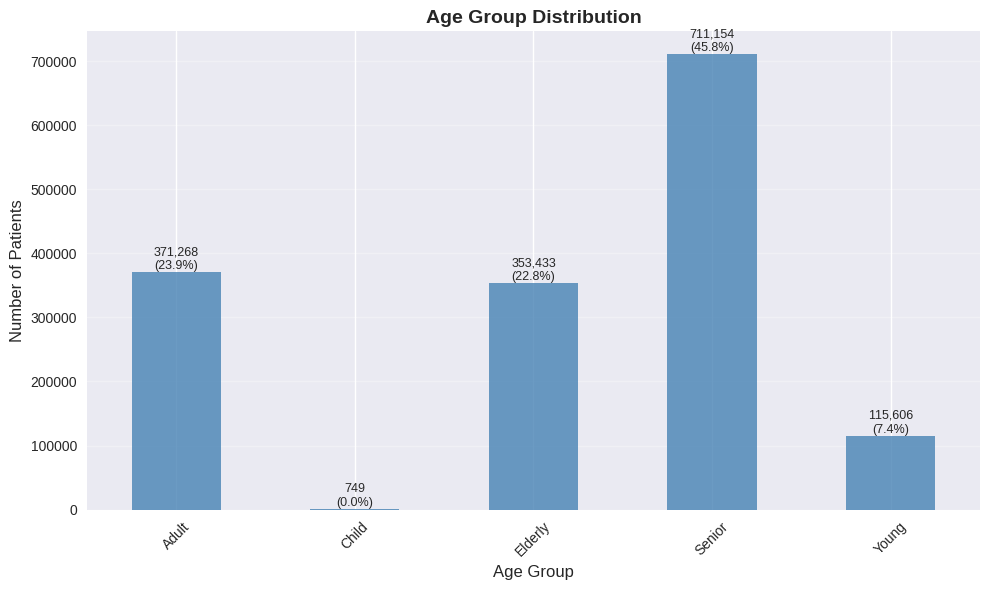

 Age distribution saved to outputs/age_distribution.png


In [89]:
import os

plt.figure(figsize=(10, 6))
age_dist.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Age Group Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, (group, count) in enumerate(age_dist.items()):
    percentage = (count / len(df_clean)) * 100
    plt.text(i, count, f"{count:,}\n({percentage:.1f}%)",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

plt.savefig('outputs/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Age distribution saved to outputs/age_distribution.png")

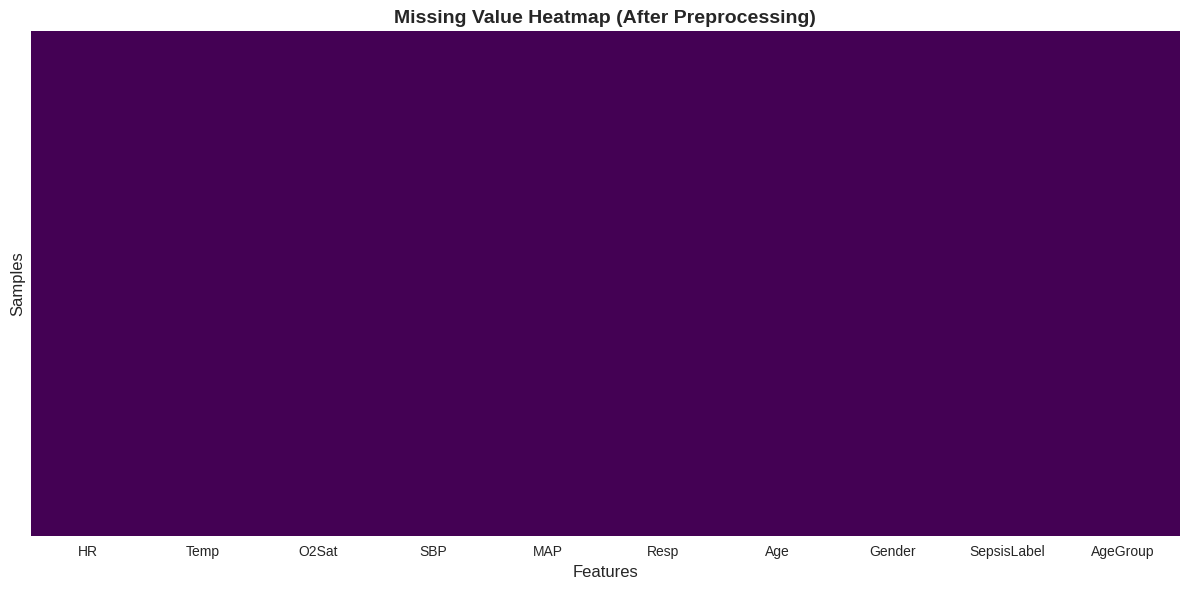

 Missing value heatmap saved


In [90]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_clean.isnull(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (After Preprocessing)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Samples', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/missing_value_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Missing value heatmap saved")

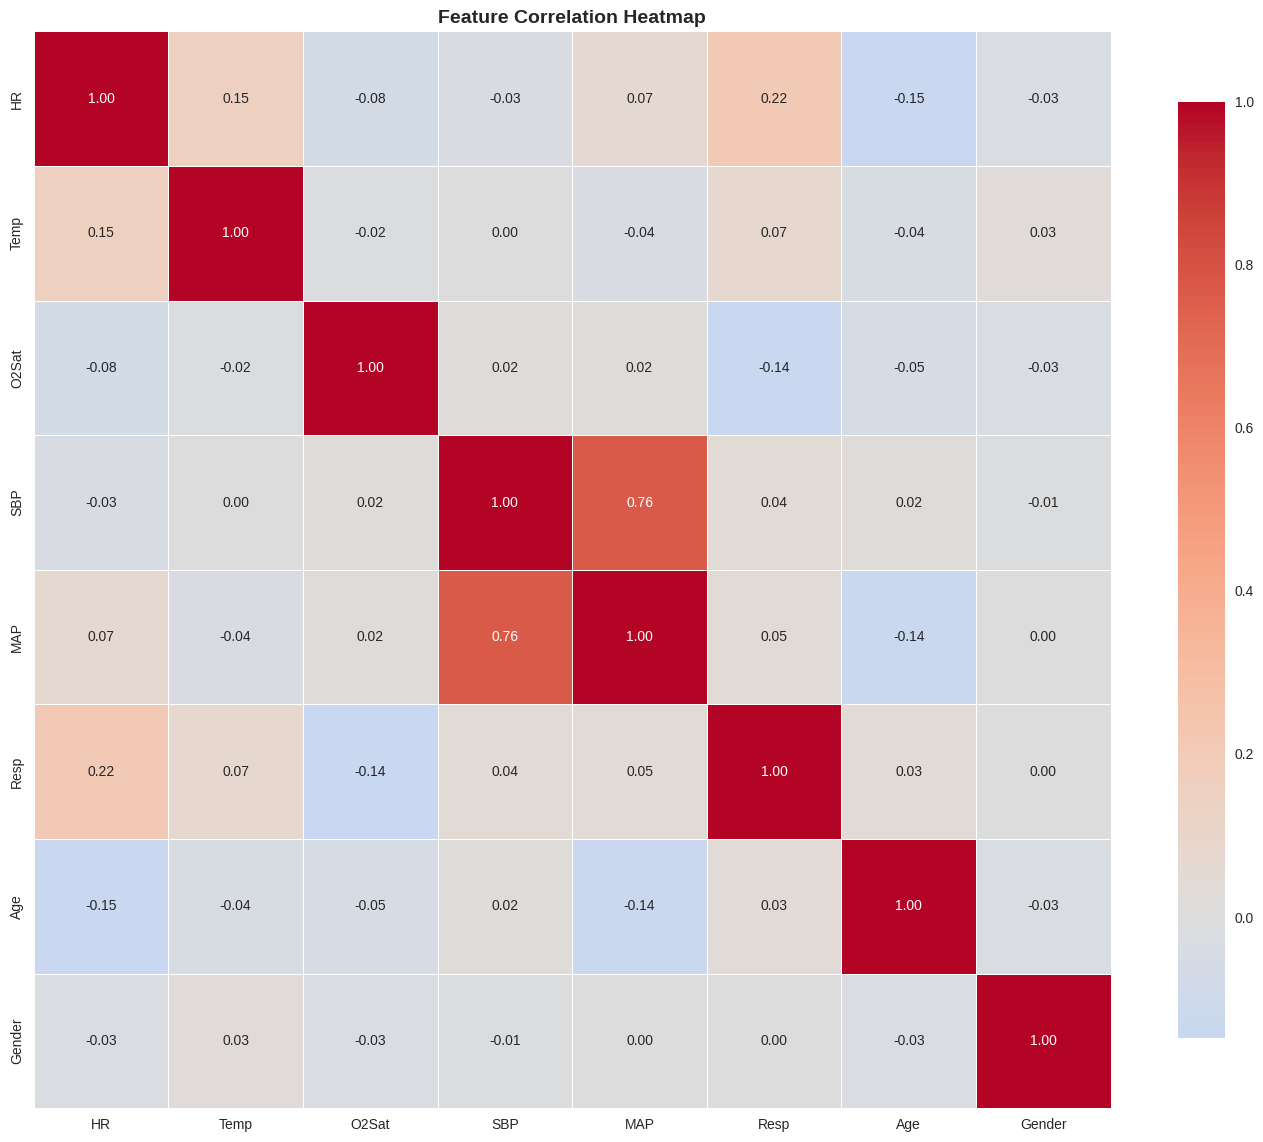

 Correlation heatmap saved

Top features correlated with Heart Rate:
  Resp: 0.218
  Temp: 0.151
  Age: 0.148
  O2Sat: 0.076
  MAP: 0.069


In [91]:
corr_matrix = df_clean[available_features].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Correlation heatmap saved")
hr_corr = corr_matrix['HR'].abs().sort_values(ascending=False)
print("\nTop features correlated with Heart Rate:")
for feature, corr in hr_corr[1:6].items():
    print(f"  {feature}: {corr:.3f}")


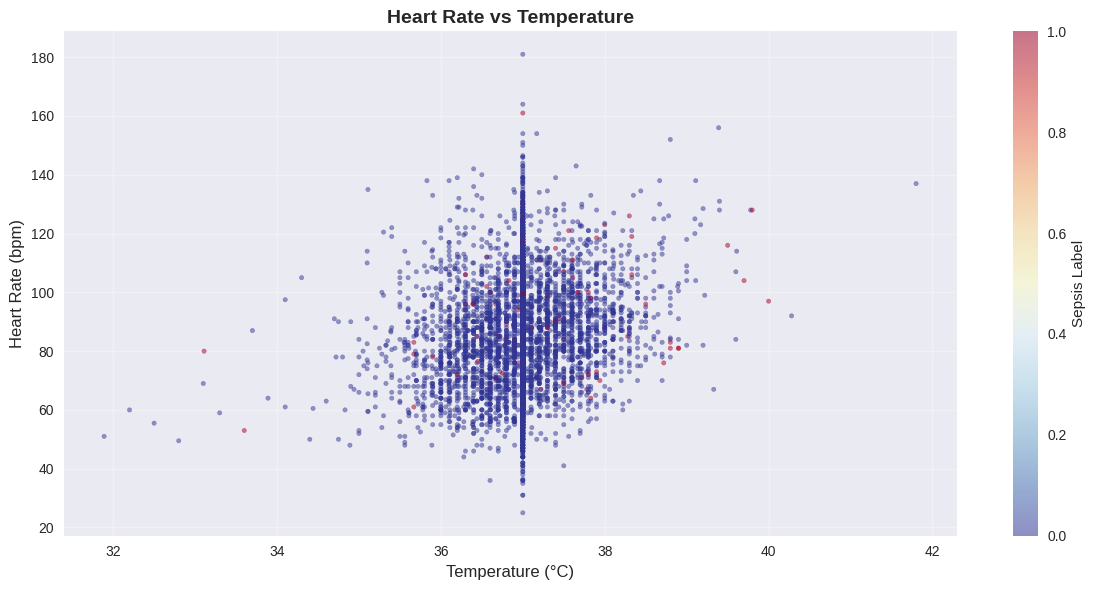

 HR vs Temperature scatter plot saved


In [92]:
sample_data = df_clean.sample(n=min(10000, len(df_clean)), random_state=42)
plt.figure(figsize=(12, 6))
scatter = plt.scatter(sample_data['Temp'], sample_data['HR'],
                      c=sample_data['SepsisLabel'], cmap='RdYlBu_r',
                      alpha=0.5, s=10)
plt.colorbar(scatter, label='Sepsis Label')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Heart Rate (bpm)', fontsize=12)
plt.title('Heart Rate vs Temperature', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/hr_vs_temperature.png', dpi=300, bbox_inches='tight')
plt.show()
print(" HR vs Temperature scatter plot saved")

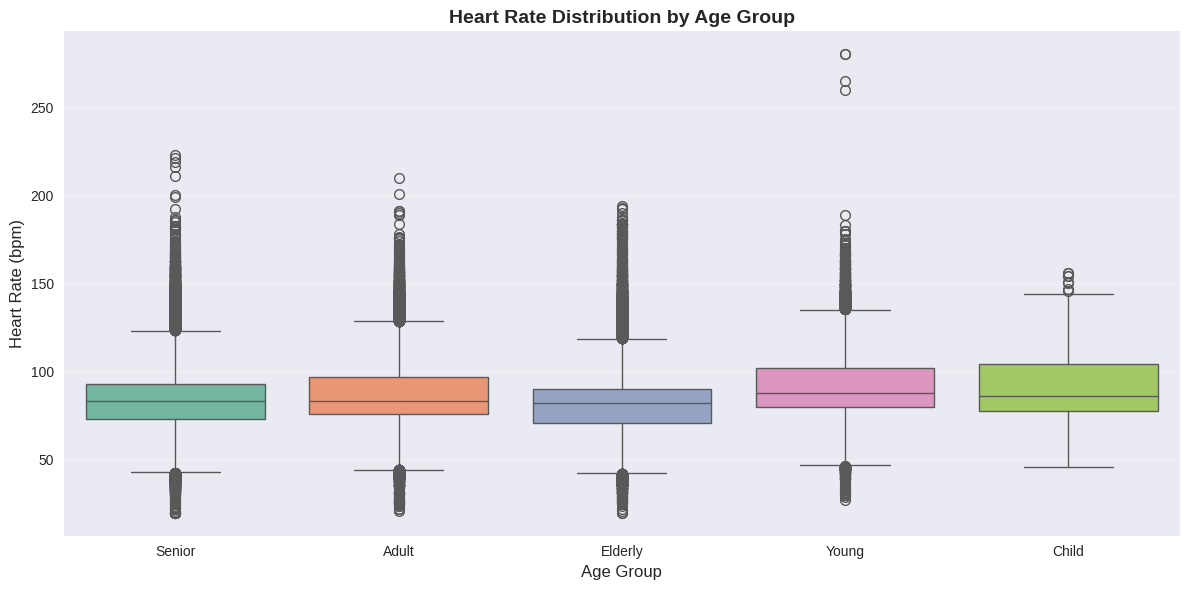

 HR by Age Group plot saved

Average Heart Rate by Age Group:
  Adult: 86.61 bpm
  Child: 90.09 bpm
  Elderly: 81.83 bpm
  Senior: 83.72 bpm
  Young: 90.29 bpm


In [93]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='AgeGroup', y='HR', palette='Set2')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Heart Rate (bpm)', fontsize=12)
plt.title('Heart Rate Distribution by Age Group', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/hr_by_age_group.png', dpi=300, bbox_inches='tight')
plt.show()
print(" HR by Age Group plot saved")
print("\nAverage Heart Rate by Age Group:")
for group in sorted(df_clean['AgeGroup'].unique()):
    avg_hr = df_clean[df_clean['AgeGroup'] == group]['HR'].mean()
    print(f"  {group}: {avg_hr:.2f} bpm")


In [94]:
X = df_clean[available_features]
y = df_clean['SepsisLabel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*60)
print("DATA SPLIT SUMMARY")
print("="*60)
print(f"Total samples: {len(X):,}")
print(f"Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

DATA SPLIT SUMMARY
Total samples: 1,552,210
Training samples: 1,241,768 (80.0%)
Testing samples: 310,442 (20.0%)

Class distribution in training set:
SepsisLabel
0    1219435
1      22333
Name: count, dtype: int64

Class distribution in test set:
SepsisLabel
0    304859
1      5583
Name: count, dtype: int64


In [95]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(" Feature scaling completed!")
print(f"\nScaled training data shape: {X_train_scaled_df.shape}")
print(f"Scaled test data shape: {X_test_scaled_df.shape}")

print("\nFirst 5 rows of scaled training data:")
display(X_train_scaled_df.head())


 Feature scaling completed!

Scaled training data shape: (1241768, 8)
Scaled test data shape: (310442, 8)

First 5 rows of scaled training data:


,HR,Temp,O2Sat,SBP,MAP,Resp,Age,Gender
0,0.153622,0.017436,0.255301,-0.667879,-0.660221,-0.557469,1.018642,-1.126419
1,1.794988,-0.116592,0.983406,-0.249184,-0.877775,0.294342,0.875192,-1.126419
2,0.518370,0.017436,-1.564961,-0.481792,-0.137569,0.081389,-0.653317,0.887769
3,1.187075,2.697992,-0.472804,-0.528314,-0.594890,-0.131563,0.277584,0.887769
4,-0.271917,0.017436,0.619353,1.286030,0.189088,-0.344516,0.427139,-1.126419


In [97]:
#Logisric regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("="*60)
print("LOGISTIC REGRESSION - BASELINE MODEL")
print("="*60)
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

results = {
    'Model': ['Logistic Regression'],
    'Accuracy': [lr_accuracy],
    'Precision': [lr_precision],
    'Recall': [lr_recall],
    'F1 Score': [lr_f1]
}


LOGISTIC REGRESSION - BASELINE MODEL
Accuracy:  0.9820
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


In [98]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("="*60)
print("RANDOM FOREST CLASSIFIER")
print("="*60)
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

results['Model'].append('Random Forest')
results['Accuracy'].append(rf_accuracy)
results['Precision'].append(rf_precision)
results['Recall'].append(rf_recall)
results['F1 Score'].append(rf_f1)

RANDOM FOREST CLASSIFIER
Accuracy:  0.9820
Precision: 0.5000
Recall:    0.0002
F1 Score:  0.0004


In [99]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("="*60)
print("XGBOOST CLASSIFIER")
print("="*60)
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")

results['Model'].append('XGBoost')
results['Accuracy'].append(xgb_accuracy)
results['Precision'].append(xgb_precision)
results['Recall'].append(xgb_recall)
results['F1 Score'].append(xgb_f1)

XGBOOST CLASSIFIER
Accuracy:  0.9820
Precision: 0.6667
Recall:    0.0004
F1 Score:  0.0007


In [100]:
#LSTM Model
sequence_length = 5

def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:(i + seq_length)])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, sequence_length)

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Testing sequences shape: {X_test_seq.shape}")


Training sequences shape: (1241763, 5, 8)
Testing sequences shape: (310437, 5, 8)


In [101]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(sequence_length, X_train_scaled.shape[1])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nLSTM Model Architecture:")
lstm_model.summary()


LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [103]:
# Train LSTM model
print("Training LSTM model...")
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=08,
    batch_size=64,
    validation_data=(X_test_seq, y_test_seq),
    callbacks=[early_stopping],
    verbose=1
)

Training LSTM model...
Epoch 1/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 207s 11ms/step - accuracy: 0.9820 - loss: 0.0904 - val_accuracy: 0.9820 - val_loss: 0.0901
Epoch 2/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 207s 11ms/step - accuracy: 0.9820 - loss: 0.0902 - val_accuracy: 0.9820 - val_loss: 0.0902
Epoch 3/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 208s 11ms/step - accuracy: 0.9820 - loss: 0.0902 - val_accuracy: 0.9820 - val_loss: 0.0901
Epoch 4/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 258s 11ms/step - accuracy: 0.9820 - loss: 0.0902 - val_accuracy: 0.9820 - val_loss: 0.0901
Epoch 5/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 208s 11ms/step - accuracy: 0.9820 - loss: 0.0901 - val_accuracy: 0.9820 - val_loss: 0.0902
Epoch 6/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 206s 11ms/step - accuracy: 0.9820 - loss: 0.0902 - val_accuracy: 0.9820 - val_loss: 0.0901
Epoch 7/30
19403/19403 ━━━━━━━━━━━━━━━━━━━━ 263s 11ms/step - accuracy: 0.9820 - loss: 0.0901 - val_accuracy: 0.9820 - val_loss: 0.0901
Epoch 8/30
19403/19403 ━━━━━━━━━

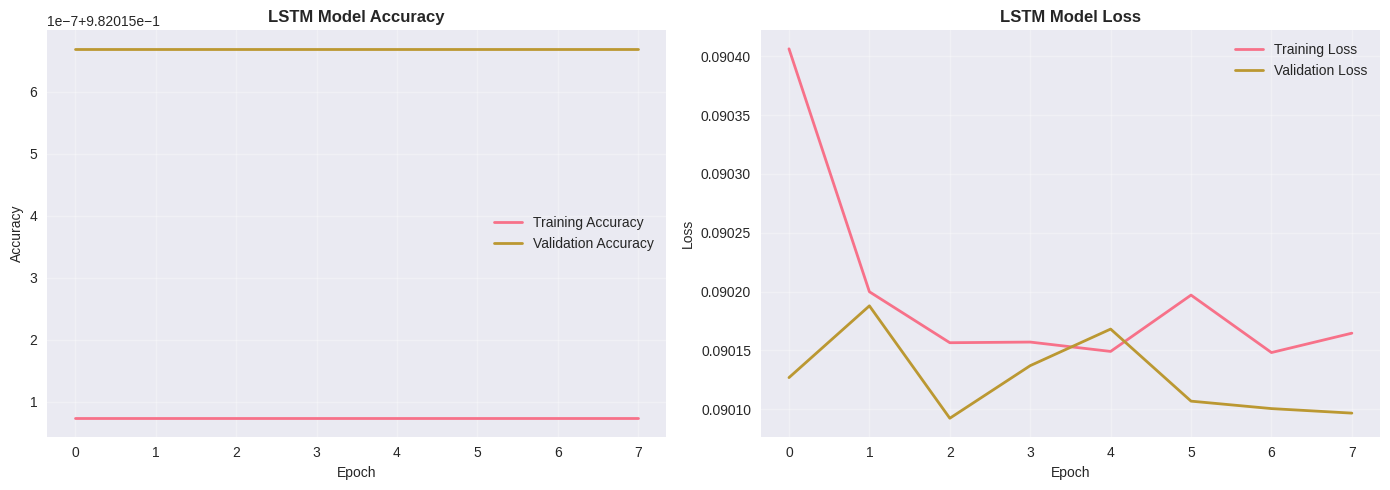

 LSTM training history saved


In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('LSTM Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=10)
axes[0].set_ylabel('Accuracy', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('LSTM Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=10)
axes[1].set_ylabel('Loss', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/lstm_training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print(" LSTM training history saved")


In [105]:
lstm_pred_proba = lstm_model.predict(X_test_seq)
lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()

lstm_accuracy = accuracy_score(y_test_seq, lstm_pred)
lstm_precision = precision_score(y_test_seq, lstm_pred)
lstm_recall = recall_score(y_test_seq, lstm_pred)
lstm_f1 = f1_score(y_test_seq, lstm_pred)

print("="*60)
print("LSTM DEEP LEARNING MODEL")
print("="*60)
print(f"Accuracy:  {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall:    {lstm_recall:.4f}")
print(f"F1 Score:  {lstm_f1:.4f}")

results['Model'].append('LSTM')
results['Accuracy'].append(lstm_accuracy)
results['Precision'].append(lstm_precision)
results['Recall'].append(lstm_recall)
results['F1 Score'].append(lstm_f1)

9702/9702 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step
LSTM DEEP LEARNING MODEL
Accuracy:  0.9820
Precision: 0.0000
Recall:    0.0000
F1 Score:  0.0000


In [106]:
class AgeTemperatureAdaptiveHRModel:
    def __init__(self):
        self.base_hr_ranges = {
            'Child': {'min': 70, 'max': 120},      # Children: 70-120 bpm
            'Young': {'min': 60, 'max': 100},      # Young adults: 60-100 bpm
            'Adult': {'min': 60, 'max': 100},      # Adults: 60-100 bpm
            'Senior': {'min': 60, 'max': 100},     # Seniors: 60-100 bpm
            'Elderly': {'min': 50, 'max': 90}      # Elderly: 50-90 bpm
        }

        self.temp_adjustment_factor = 10
        self.normal_temp = 37.0

    def get_age_group(self, age):
        if age < 18:
            return 'Child'
        elif age <= 35:
            return 'Young'
        elif age <= 55:
            return 'Adult'
        elif age <= 75:
            return 'Senior'
        else:
            return 'Elderly'

    def estimate_expected_hr(self, age, temperature):
        age_group = self.get_age_group(age)
        base_hr_range = self.base_hr_ranges[age_group]
        base_hr = (base_hr_range['min'] + base_hr_range['max']) / 2
        temp_diff = max(0, temperature - self.normal_temp)
        temp_adjustment = temp_diff * self.temp_adjustment_factor

        expected_hr = base_hr + temp_adjustment

        return expected_hr, age_group

    def get_expected_hr_range(self, age, temperature):
        age_group = self.get_age_group(age)
        base_hr_range = self.base_hr_ranges[age_group]

        temp_diff = max(0, temperature - self.normal_temp)
        temp_adjustment = temp_diff * self.temp_adjustment_factor

        expected_min = base_hr_range['min'] + temp_adjustment
        expected_max = base_hr_range['max'] + temp_adjustment

        return expected_min, expected_max

    def calculate_deviation(self, actual_hr, expected_hr):
        deviation = actual_hr - expected_hr
        return deviation

    def calculate_risk_score(self, deviation, expected_hr):
        abs_deviation = abs(deviation)
        percent_deviation = (abs_deviation / expected_hr) * 100
        risk_score = min(100, abs_deviation * 2 + percent_deviation / 2)

        return risk_score

    def get_risk_level(self, risk_score):
        if risk_score < 20:
            return 'Low'
        elif risk_score < 50:
            return 'Medium'
        else:
            return 'High'

    def predict(self, age, temperature, actual_hr, other_vitals=None):
        expected_hr, age_group = self.estimate_expected_hr(age, temperature)
        expected_min, expected_max = self.get_expected_hr_range(age, temperature)
        deviation = self.calculate_deviation(actual_hr, expected_hr)
        risk_score = self.calculate_risk_score(deviation, expected_hr)
        risk_level = self.get_risk_level(risk_score)
        in_range = expected_min <= actual_hr <= expected_max

        return {
            'age_group': age_group,
            'expected_hr': expected_hr,
            'expected_hr_range': (expected_min, expected_max),
            'actual_hr': actual_hr,
            'deviation': deviation,
            'risk_score': risk_score,
            'risk_level': risk_level,
            'in_normal_range': in_range
        }
novel_model = AgeTemperatureAdaptiveHRModel()
print(" Age-Adaptive and Temperature-Aware HR Model initialized!")
print("\nModel Features:")
print("  - Age-adaptive HR estimation")
print("  - Temperature-aware adjustment")
print("  - Deviation calculation")
print("  - Risk score generation")


 Age-Adaptive and Temperature-Aware HR Model initialized!

Model Features:
  - Age-adaptive HR estimation
  - Temperature-aware adjustment
  - Deviation calculation
  - Risk score generation


In [107]:
print("Applying novel model to test data...")

test_predictions = []
for idx, row in X_test.iterrows():
    prediction = novel_model.predict(
        age=row['Age'],
        temperature=row['Temp'],
        actual_hr=row['HR']
    )
    test_predictions.append(prediction)
test_predictions_df = pd.DataFrame(test_predictions)
test_predictions_df['SepsisLabel'] = y_test.values
test_predictions_df['RiskPrediction'] = (test_predictions_df['risk_score'] > 30).astype(int)

print(f" Novel model predictions generated for {len(test_predictions_df):,} samples")
print("\nSample predictions:")
display(test_predictions_df.head(10))


Applying novel model to test data...
 Novel model predictions generated for 310,442 samples

Sample predictions:


,age_group,expected_hr,expected_hr_range,actual_hr,deviation,risk_score,risk_level,in_normal_range,SepsisLabel,RiskPrediction
0,Adult,80.0,"(60, 100)",72.0,-8.0,21.000000,Medium,True,0,0
1,Elderly,70.0,"(50, 90)",88.5,18.5,50.214286,High,True,0,1
2,Adult,80.0,"(60, 100)",80.0,0.0,0.000000,Low,True,0,0
3,Senior,80.0,"(60, 100)",91.0,11.0,28.875000,Medium,True,0,0
4,Adult,80.0,"(60, 100)",73.0,-7.0,18.375000,Low,True,0,0
5,Elderly,70.0,"(50, 90)",71.0,1.0,2.714286,Low,True,0,0
6,Senior,80.0,"(60, 100)",108.0,28.0,73.500000,High,False,0,1
7,Senior,80.0,"(60, 100)",59.0,-21.0,55.125000,High,False,0,1
8,Elderly,70.0,"(50, 90)",65.5,-4.5,12.214286,Low,True,0,0
9,Adult,80.0,"(60, 100)",83.5,3.5,9.187500,Low,True,0,0


In [108]:
novel_accuracy = accuracy_score(y_test, test_predictions_df['RiskPrediction'])
novel_precision = precision_score(y_test, test_predictions_df['RiskPrediction'])
novel_recall = recall_score(y_test, test_predictions_df['RiskPrediction'])
novel_f1 = f1_score(y_test, test_predictions_df['RiskPrediction'])

print("="*60)
print("NOVEL MODEL PERFORMANCE")
print("Age-Adaptive and Temperature-Aware HR Monitoring")
print("="*60)
print(f"Accuracy:  {novel_accuracy:.4f}")
print(f"Precision: {novel_precision:.4f}")
print(f"Recall:    {novel_recall:.4f}")
print(f"F1 Score:  {novel_f1:.4f}")

results['Model'].append('Novel Model (Age-Adaptive)')
results['Accuracy'].append(novel_accuracy)
results['Precision'].append(novel_precision)
results['Recall'].append(novel_recall)
results['F1 Score'].append(novel_f1)


NOVEL MODEL PERFORMANCE
Age-Adaptive and Temperature-Aware HR Monitoring
Accuracy:  0.5304
Precision: 0.0210
Recall:    0.5493
F1 Score:  0.0404


In [109]:
results_df = pd.DataFrame(results)

print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
display(results_df)
results_df_sorted = results_df.sort_values('F1 Score', ascending=False)
print("\n" + "="*80)
print("RANKED MODELS (BY F1 SCORE)")
print("="*80)
for idx, row in results_df_sorted.iterrows():
    print(f"{row['Model']:<30} F1: {row['F1 Score']:.4f}")


MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982016,0.000000,0.000000,0.000000
1,Random Forest,0.982016,0.500000,0.000179,0.000358
2,XGBoost,0.982019,0.666667,0.000358,0.000716
3,LSTM,0.982016,0.000000,0.000000,0.000000
4,Novel Model (Age-Adaptive),0.530376,0.020958,0.549346,0.040375



RANKED MODELS (BY F1 SCORE)
Novel Model (Age-Adaptive)     F1: 0.0404
XGBoost                        F1: 0.0007
Random Forest                  F1: 0.0004
Logistic Regression            F1: 0.0000
LSTM                           F1: 0.0000


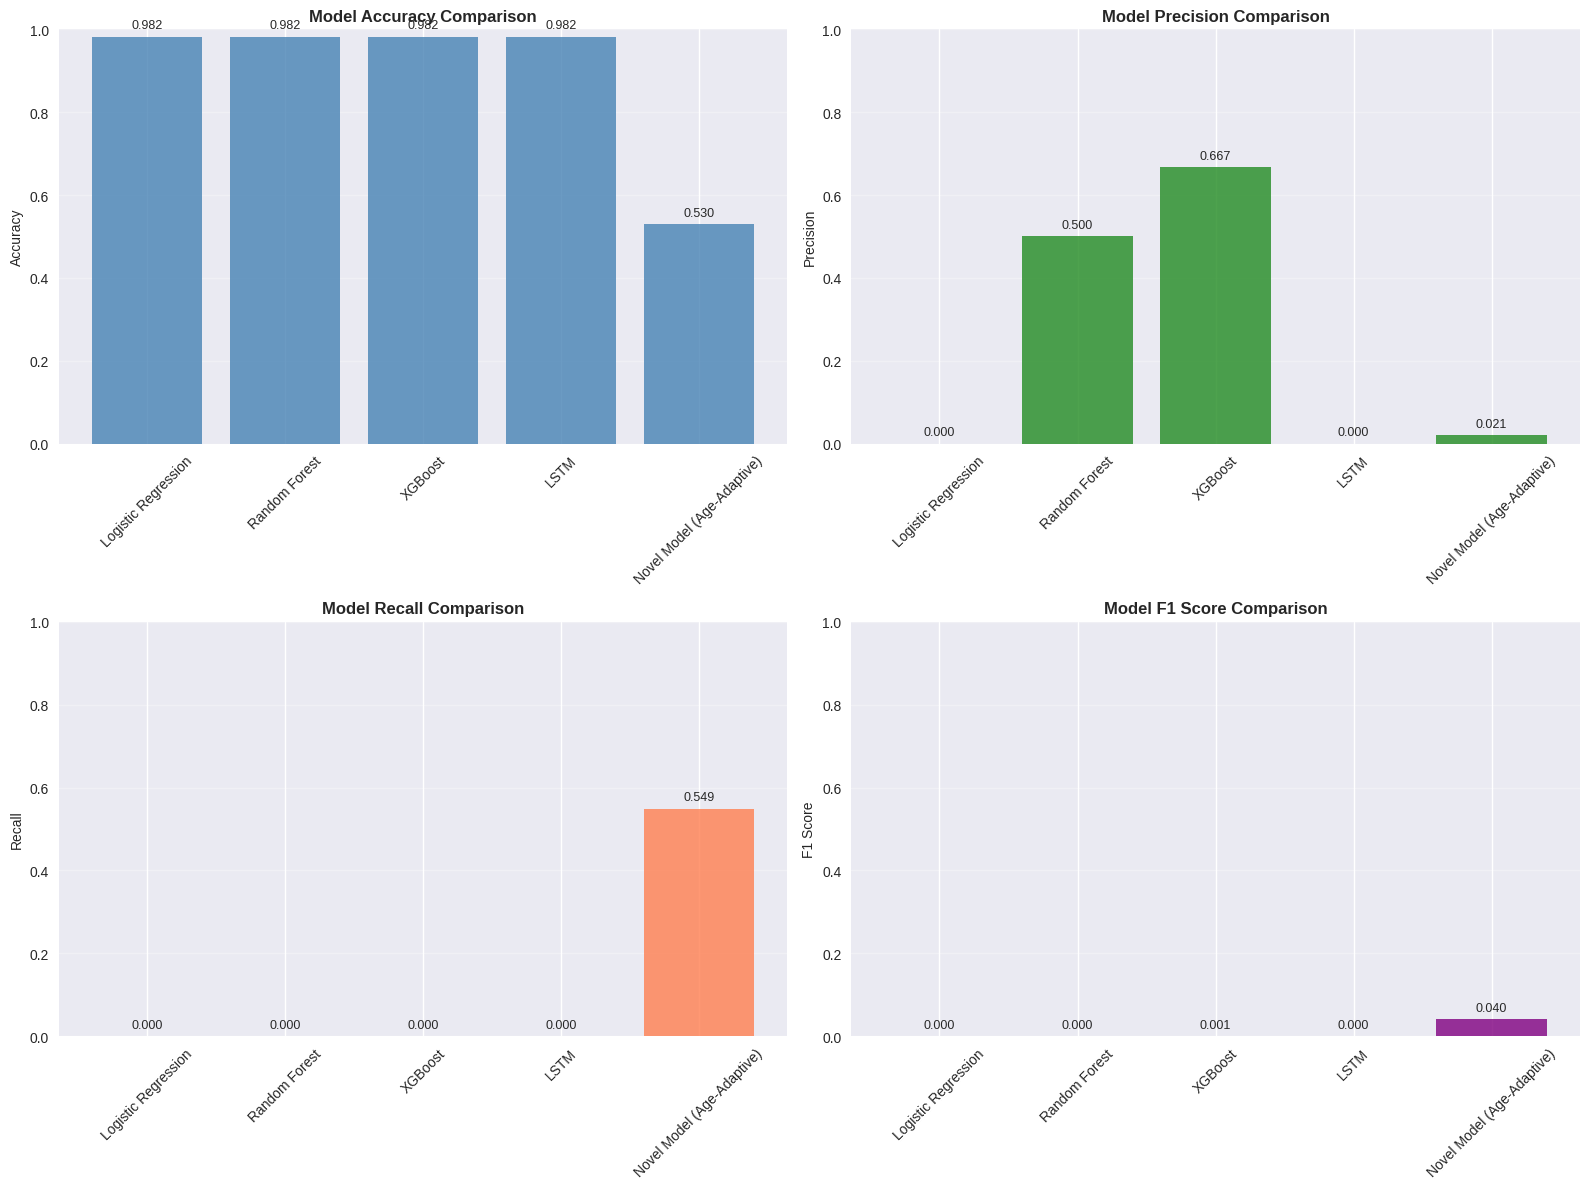

 Model comparison visualization saved


In [111]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].bar(results_df['Model'], results_df['Accuracy'], color='steelblue', alpha=0.8)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=10)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Accuracy']):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[0, 1].bar(results_df['Model'], results_df['Precision'], color='forestgreen', alpha=0.8)
axes[0, 1].set_title('Model Precision Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Precision', fontsize=10)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Precision']):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1, 0].bar(results_df['Model'], results_df['Recall'], color='coral', alpha=0.8)
axes[1, 0].set_title('Model Recall Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Recall', fontsize=10)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['Recall']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1, 1].bar(results_df['Model'], results_df['F1 Score'], color='purple', alpha=0.8)
axes[1, 1].set_title('Model F1 Score Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('F1 Score', fontsize=10)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(results_df['F1 Score']):
    axes[1, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Model comparison visualization saved")


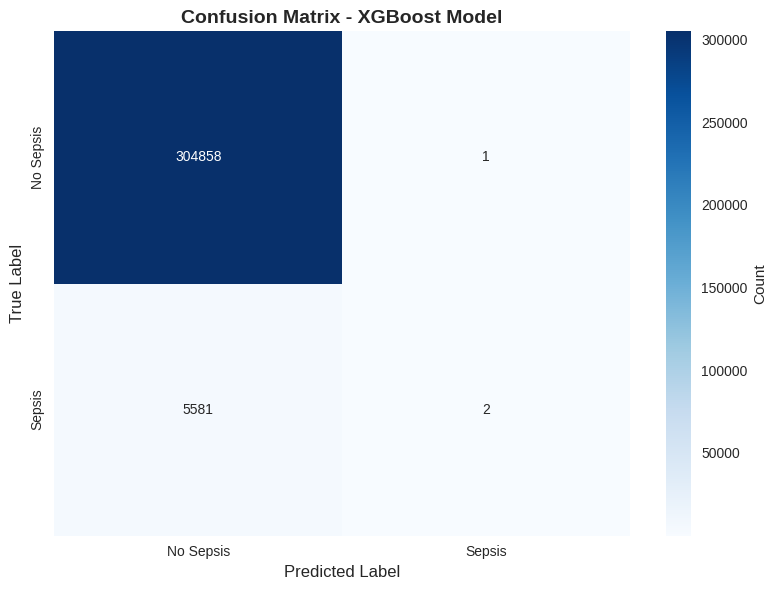

 Confusion matrix saved

Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    304859
           1       0.67      0.00      0.00      5583

    accuracy                           0.98    310442
   macro avg       0.82      0.50      0.50    310442
weighted avg       0.98      0.98      0.97    310442



In [112]:
cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Sepsis', 'Sepsis'],
            yticklabels=['No Sepsis', 'Sepsis'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - XGBoost Model', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved")

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, xgb_pred))


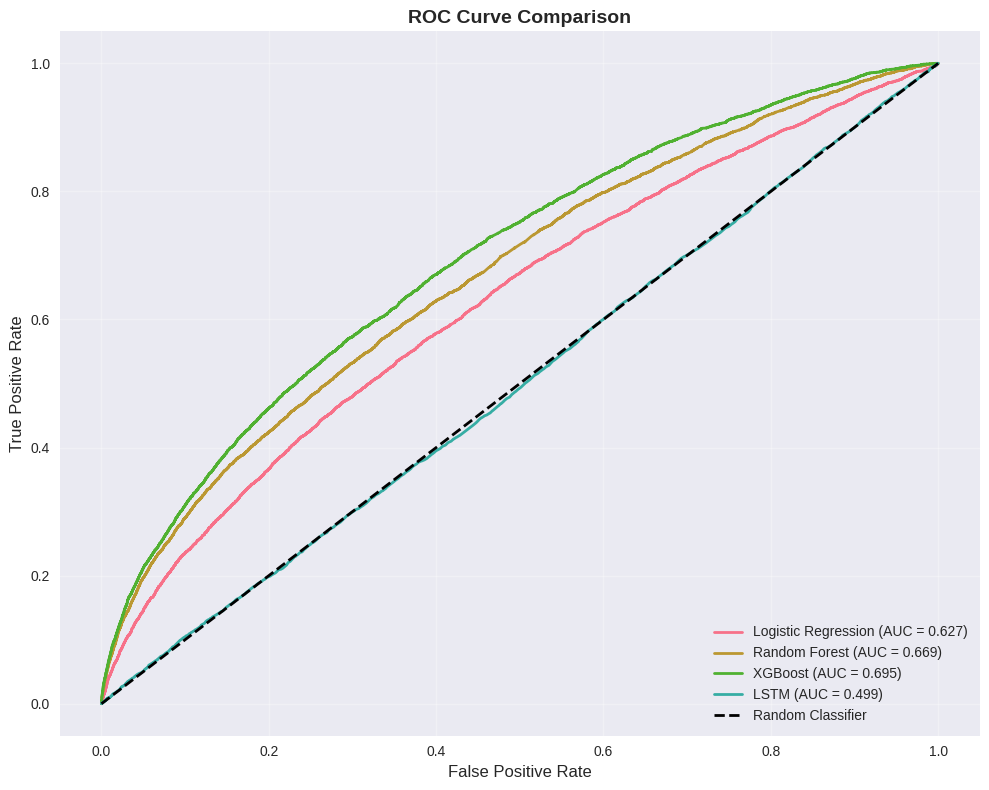

 ROC curves saved


In [113]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_seq, lstm_pred_proba)

auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})', linewidth=2)
plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC = {auc_lstm:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print(" ROC curves saved")


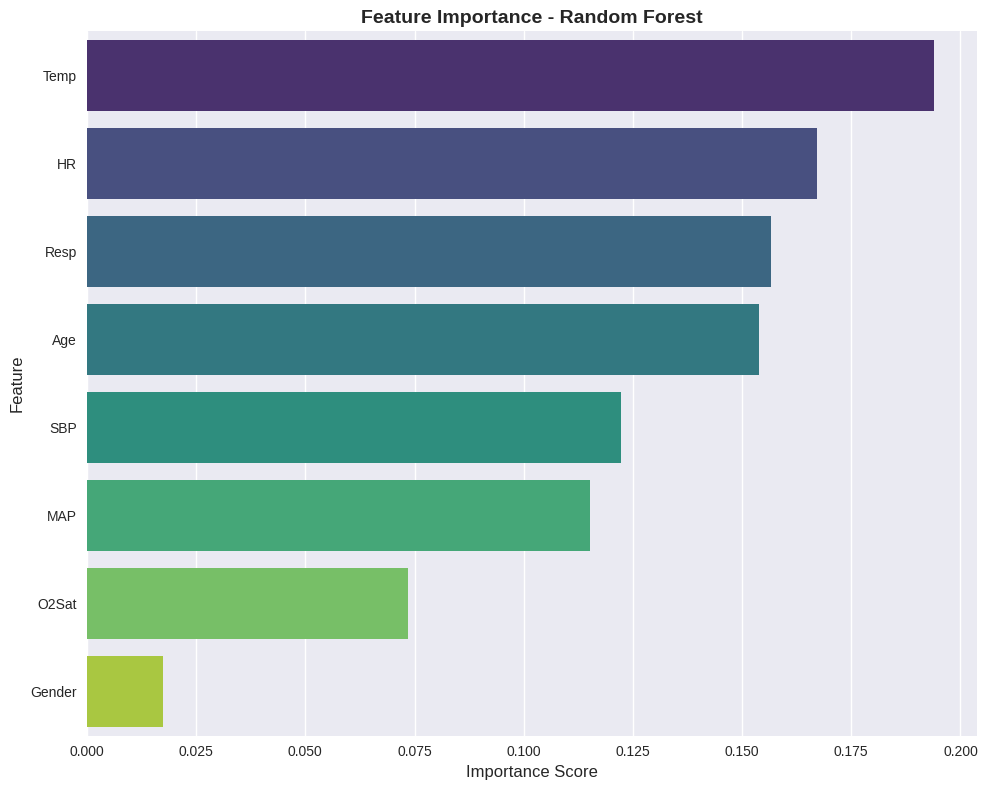

 Feature importance plot saved

Feature Importance Ranking:


,Feature,Importance
1,Temp,0.193970
0,HR,0.167218
5,Resp,0.156654
6,Age,0.153827
3,SBP,0.122259
4,MAP,0.115165
2,O2Sat,0.073562
7,Gender,0.017345


In [114]:
feature_importance = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Feature importance plot saved")

print("\nFeature Importance Ranking:")
display(feature_importance_df)


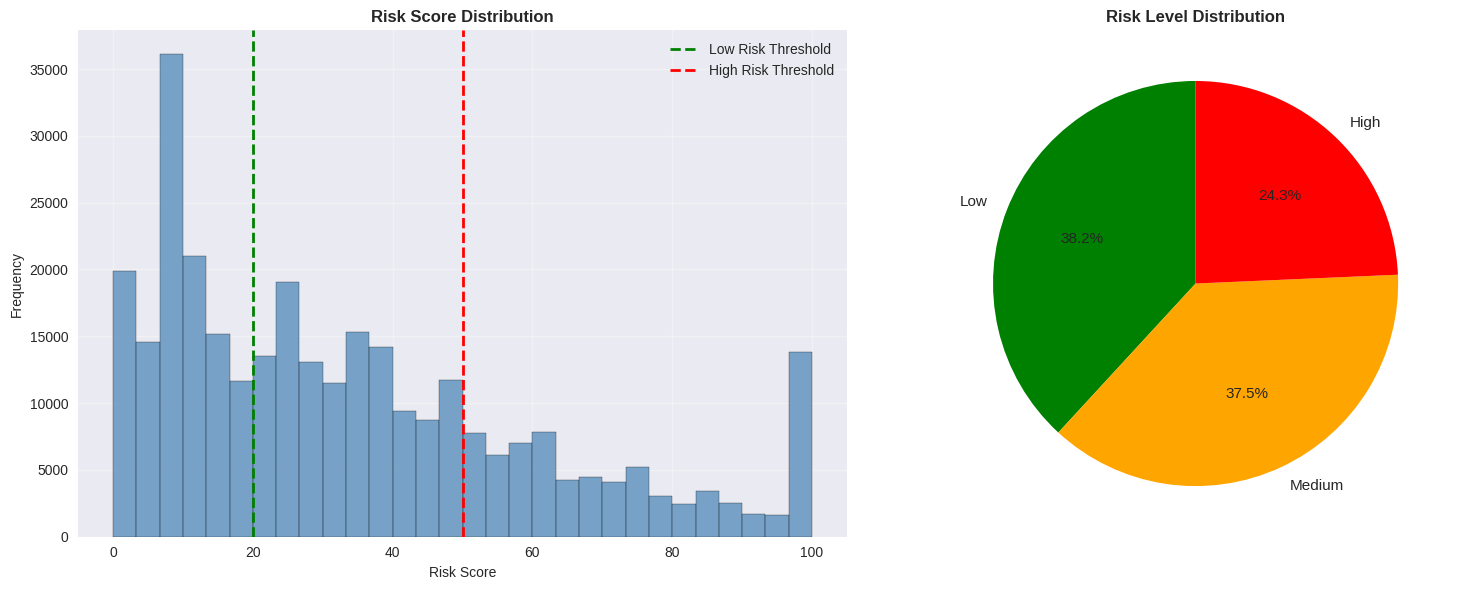

 Risk distribution visualizations saved


In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(test_predictions_df['risk_score'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(x=20, color='green', linestyle='--', linewidth=2, label='Low Risk Threshold')
axes[0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='High Risk Threshold')
axes[0].set_title('Risk Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Risk Score', fontsize=10)
axes[0].set_ylabel('Frequency', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

risk_level_counts = test_predictions_df['risk_level'].value_counts()
colors = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
axes[1].pie(risk_level_counts.values, labels=risk_level_counts.index,
           autopct='%1.1f%%', colors=[colors[x] for x in risk_level_counts.index],
           startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Risk Level Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Risk distribution visualizations saved")


In [118]:
def real_time_monitor(age, hr, temperature, o2_sat=None, sbp=None,
                      map_val=None, resp=None):
    result = novel_model.predict(age, temperature, hr)
    print("="*70)
    print(" REAL-TIME HEART RATE MONITORING")
    print("="*70)
    print(f"\n PATIENT VITAL SIGNS:")
    print(f"  Age:           {age} years ({result['age_group']})")
    print(f"  Temperature:   {temperature}°C")
    print(f"  Heart Rate:    {hr} bpm")

    if o2_sat is not None:
        print(f"  O2 Saturation: {o2_sat}%")
    if sbp is not None:
        print(f"  SBP:           {sbp} mmHg")
    if map_val is not None:
        print(f"  MAP:           {map_val} mmHg")
    if resp is not None:
        print(f"  Respiration:   {resp} bpm")

    print(f"\n MONITORING RESULTS:")
    print(f"  Expected HR Range: {result['expected_hr_range'][0]:.0f}-{result['expected_hr_range'][1]:.0f} bpm")
    print(f"  Expected HR:       {result['expected_hr']:.1f} bpm")
    print(f"  Actual HR:         {result['actual_hr']:.0f} bpm")
    print(f"  Deviation:         {result['deviation']:+.1f} bpm")

    print(f"\n RISK ASSESSMENT:")
    print(f"  Risk Score:    {result['risk_score']:.1f}/100")
    print(f"  Risk Level:    {result['risk_level']}")

    if result['risk_level'] == 'Low':
        print("  Status:        ✅ NORMAL - No immediate action required")
    elif result['risk_level'] == 'Medium':
        print("  Status:        ⚠️  ATTENTION NEEDED - Monitor closely")
    else:
        print("  Status:        🚨 CRITICAL - Immediate medical intervention needed")

    print("="*70)
    return result
print(" Real-time monitoring function defined!")


 Real-time monitoring function defined!


In [119]:
# Example 1: Child with fever and elevated HR
result1 = real_time_monitor(
    age=5,
    hr=160,
    temperature=38.5,
    o2_sat=98,
    sbp=90,
    resp=25
)

 REAL-TIME HEART RATE MONITORING

 PATIENT VITAL SIGNS:
  Age:           5 years (Child)
  Temperature:   38.5°C
  Heart Rate:    160 bpm
  O2 Saturation: 98%
  SBP:           90 mmHg
  Respiration:   25 bpm

 MONITORING RESULTS:
  Expected HR Range: 85-135 bpm
  Expected HR:       110.0 bpm
  Actual HR:         160 bpm
  Deviation:         +50.0 bpm

 RISK ASSESSMENT:
  Risk Score:    100.0/100
  Risk Level:    High
  Status:        🚨 CRITICAL - Immediate medical intervention needed


In [120]:
# Example 2: Elderly patient with normal HR
result2 = real_time_monitor(
    age=78,
    hr=75,
    temperature=37.0,
    o2_sat=96,
    sbp=130,
    resp=16
)


 REAL-TIME HEART RATE MONITORING

 PATIENT VITAL SIGNS:
  Age:           78 years (Elderly)
  Temperature:   37.0°C
  Heart Rate:    75 bpm
  O2 Saturation: 96%
  SBP:           130 mmHg
  Respiration:   16 bpm

 MONITORING RESULTS:
  Expected HR Range: 50-90 bpm
  Expected HR:       70.0 bpm
  Actual HR:         75 bpm
  Deviation:         +5.0 bpm

 RISK ASSESSMENT:
  Risk Score:    13.6/100
  Risk Level:    Low
  Status:        ✅ NORMAL - No immediate action required


In [121]:
# Example 3: Adult with abnormally low HR
result3 = real_time_monitor(
    age=45,
    hr=45,
    temperature=36.8,
    o2_sat=97,
    sbp=110,
    resp=14
)


 REAL-TIME HEART RATE MONITORING

 PATIENT VITAL SIGNS:
  Age:           45 years (Adult)
  Temperature:   36.8°C
  Heart Rate:    45 bpm
  O2 Saturation: 97%
  SBP:           110 mmHg
  Respiration:   14 bpm

 MONITORING RESULTS:
  Expected HR Range: 60-100 bpm
  Expected HR:       80.0 bpm
  Actual HR:         45 bpm
  Deviation:         -35.0 bpm

 RISK ASSESSMENT:
  Risk Score:    91.9/100
  Risk Level:    High
  Status:        🚨 CRITICAL - Immediate medical intervention needed


In [122]:
# Example 4: Young adult with high fever and very high HR
result4 = real_time_monitor(
    age=25,
    hr=140,
    temperature=39.5,
    o2_sat=95,
    sbp=105,
    resp=28
)

 REAL-TIME HEART RATE MONITORING

 PATIENT VITAL SIGNS:
  Age:           25 years (Young)
  Temperature:   39.5°C
  Heart Rate:    140 bpm
  O2 Saturation: 95%
  SBP:           105 mmHg
  Respiration:   28 bpm

 MONITORING RESULTS:
  Expected HR Range: 85-125 bpm
  Expected HR:       105.0 bpm
  Actual HR:         140 bpm
  Deviation:         +35.0 bpm

 RISK ASSESSMENT:
  Risk Score:    86.7/100
  Risk Level:    High
  Status:        🚨 CRITICAL - Immediate medical intervention needed


In [123]:
def simulate_monitoring_dashboard(age, duration_hours=24, base_temp=37.0):
    np.random.seed(42)
    time_points = pd.date_range(
        start=pd.Timestamp.now().floor('H'),
        periods=duration_hours * 4,
        freq='15min'
    )

    temperature = np.random.normal(base_temp, 0.2, len(time_points))
    fever_start = len(time_points) // 3
    fever_end = 2 * len(time_points) // 3
    temperature[fever_start:fever_end] += np.random.normal(1.5, 0.3, fever_end - fever_start)
    base_hr_min, base_hr_max = novel_model.get_expected_hr_range(age, 37.0)

    hr = []
    for i, temp in enumerate(temperature):
        expected_min, expected_max = novel_model.get_expected_hr_range(age, temp)
        base = (expected_min + expected_max) / 2

        variability = np.random.normal(0, 5)
        hr_val = base + variability
        hr.append(hr_val)

    hr = np.array(hr)
    monitoring_data = []
    for i in range(len(time_points)):
        result = novel_model.predict(age, temperature[i], hr[i])
        monitoring_data.append({
            'Time': time_points[i],
            'Temperature': temperature[i],
            'Heart Rate': hr[i],
            'Expected HR': result['expected_hr'],
            'Deviation': result['deviation'],
            'Risk Score': result['risk_score'],
            'Risk Level': result['risk_level']
        })

    monitoring_df = pd.DataFrame(monitoring_data)

    return monitoring_df, base_hr_min, base_hr_max

print(" Dashboard simulation function defined!")


 Dashboard simulation function defined!


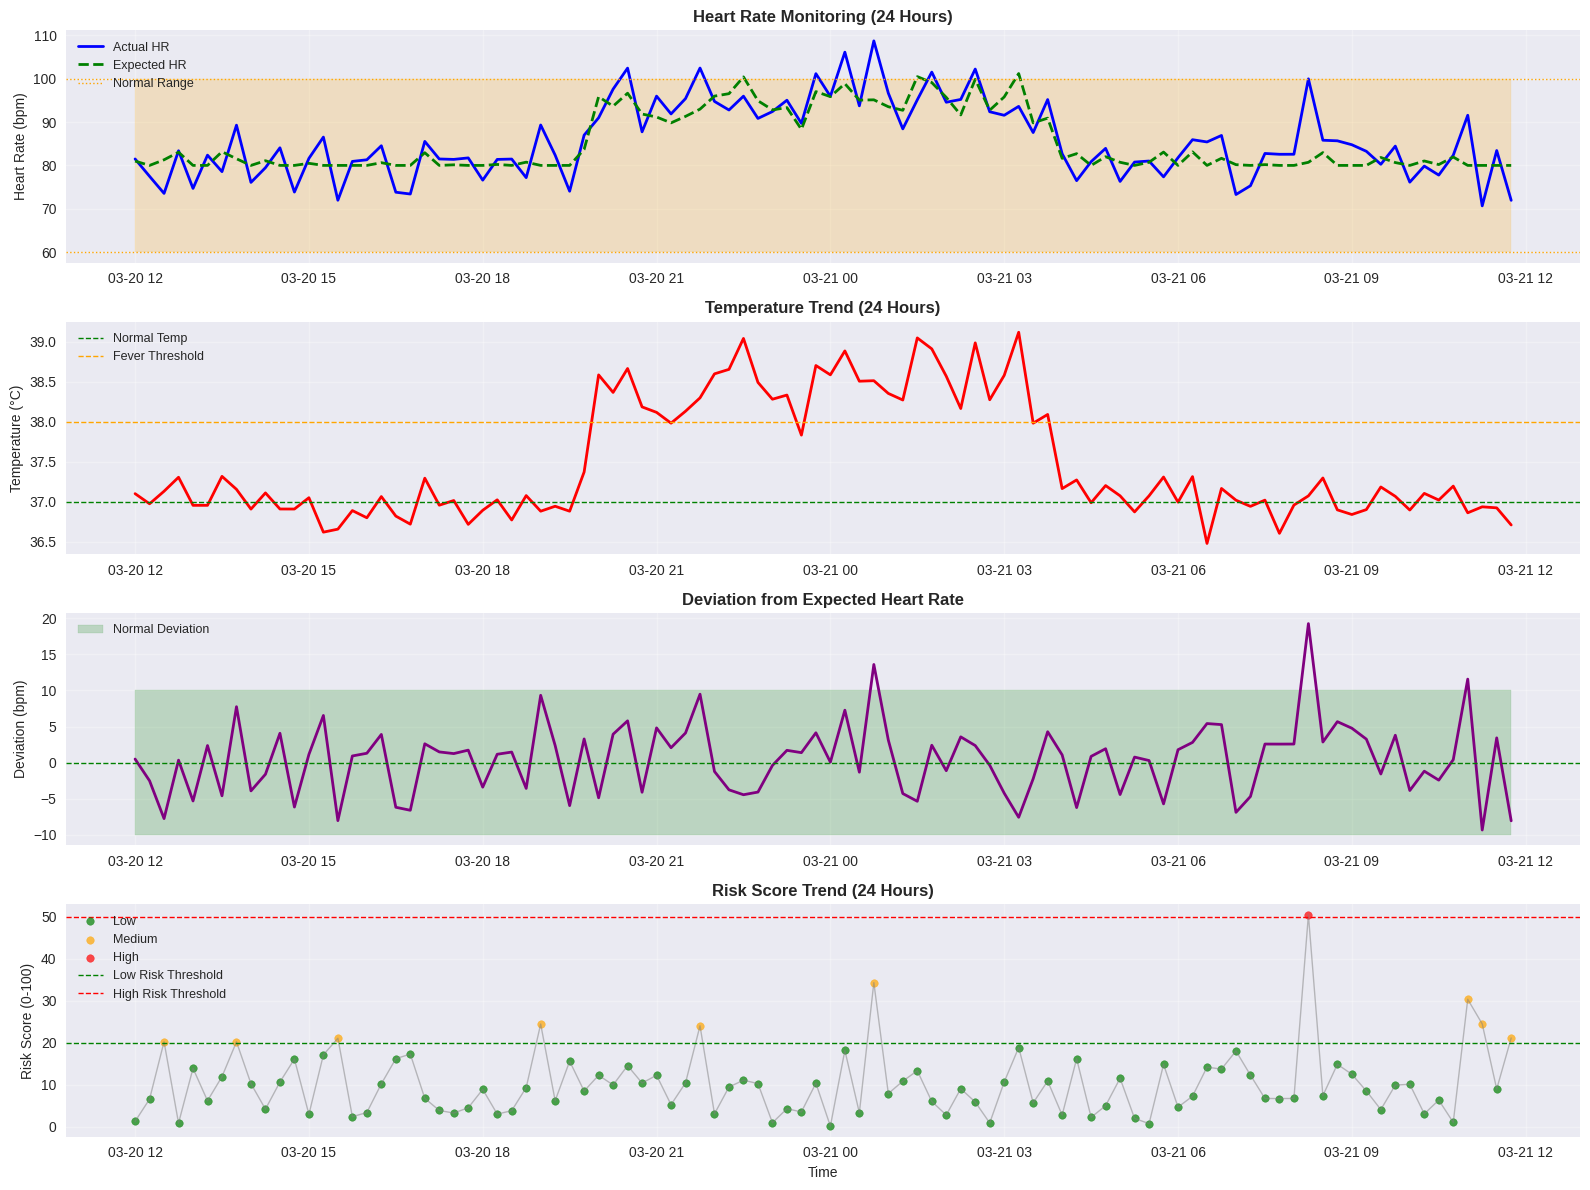

 Dashboard simulation saved

DASHBOARD SUMMARY STATISTICS

Monitoring Duration: 24 hours
Patient Age: 30 years (Young Adult)

Temperature Statistics:
  Min: 36.48°C
  Max: 39.12°C
  Avg: 37.48°C

Heart Rate Statistics:
  Min: 70.7 bpm
  Max: 108.7 bpm
  Avg: 85.8 bpm

Risk Distribution:
Risk Level
Low       86
Medium     9
High       1
Name: count, dtype: int64


In [124]:
monitoring_df, hr_min, hr_max = simulate_monitoring_dashboard(age=30, duration_hours=24)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
axes[0].plot(monitoring_df['Time'], monitoring_df['Heart Rate'],
             label='Actual HR', linewidth=2, color='blue')
axes[0].plot(monitoring_df['Time'], monitoring_df['Expected HR'],
             label='Expected HR', linewidth=2, color='green', linestyle='--')
axes[0].axhline(y=hr_min, color='orange', linestyle=':', linewidth=1, label='Normal Range')
axes[0].axhline(y=hr_max, color='orange', linestyle=':', linewidth=1)
axes[0].fill_between(monitoring_df['Time'], hr_min, hr_max, alpha=0.2, color='orange')
axes[0].set_title('Heart Rate Monitoring (24 Hours)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Heart Rate (bpm)', fontsize=10)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(monitoring_df['Time'], monitoring_df['Temperature'],
             linewidth=2, color='red')
axes[1].axhline(y=37.0, color='green', linestyle='--', linewidth=1, label='Normal Temp')
axes[1].axhline(y=38.0, color='orange', linestyle='--', linewidth=1, label='Fever Threshold')
axes[1].set_title('Temperature Trend (24 Hours)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Temperature (°C)', fontsize=10)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(monitoring_df['Time'], monitoring_df['Deviation'],
             linewidth=2, color='purple')
axes[2].axhline(y=0, color='green', linestyle='--', linewidth=1)
axes[2].fill_between(monitoring_df['Time'], -10, 10, alpha=0.2, color='green', label='Normal Deviation')
axes[2].set_title('Deviation from Expected Heart Rate', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Deviation (bpm)', fontsize=10)
axes[2].legend(loc='upper left', fontsize=9)
axes[2].grid(True, alpha=0.3)

colors_risk = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}
for risk_level in monitoring_df['Risk Level'].unique():
    subset = monitoring_df[monitoring_df['Risk Level'] == risk_level]
    axes[3].scatter(subset['Time'], subset['Risk Score'],
                   c=colors_risk[risk_level], label=risk_level, s=30, alpha=0.7)
axes[3].plot(monitoring_df['Time'], monitoring_df['Risk Score'],
             linewidth=1, color='gray', alpha=0.5)
axes[3].axhline(y=20, color='green', linestyle='--', linewidth=1, label='Low Risk Threshold')
axes[3].axhline(y=50, color='red', linestyle='--', linewidth=1, label='High Risk Threshold')
axes[3].set_title('Risk Score Trend (24 Hours)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Risk Score (0-100)', fontsize=10)
axes[3].set_xlabel('Time', fontsize=10)
axes[3].legend(loc='upper left', fontsize=9)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/dashboard_simulation.png', dpi=300, bbox_inches='tight')
plt.show()
print(" Dashboard simulation saved")

print("\n" + "="*70)
print("DASHBOARD SUMMARY STATISTICS")
print("="*70)
print(f"\nMonitoring Duration: 24 hours")
print(f"Patient Age: 30 years (Young Adult)")
print(f"\nTemperature Statistics:")
print(f"  Min: {monitoring_df['Temperature'].min():.2f}°C")
print(f"  Max: {monitoring_df['Temperature'].max():.2f}°C")
print(f"  Avg: {monitoring_df['Temperature'].mean():.2f}°C")
print(f"\nHeart Rate Statistics:")
print(f"  Min: {monitoring_df['Heart Rate'].min():.1f} bpm")
print(f"  Max: {monitoring_df['Heart Rate'].max():.1f} bpm")
print(f"  Avg: {monitoring_df['Heart Rate'].mean():.1f} bpm")
print(f"\nRisk Distribution:")
print(monitoring_df['Risk Level'].value_counts())

In [128]:
print("="*80)
print(" FINAL PROJECT RESULTS SUMMARY")
print("="*80)

print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
display(results_df_sorted)

print("\n" + "="*80)
print("NOVEL MODEL CAPABILITIES")
print("="*80)
print(" Age-Adaptive HR Estimation")
print("  - Different HR ranges for different age groups")
print("  - Child: 70-120 bpm, Young/Adult: 60-100 bpm, Elderly: 50-90 bpm")
print("")
print(" Temperature-Aware Adjustment")
print("  - Automatically adjusts expected HR based on temperature")
print("  - ~10 bpm increase per 1°C above normal")
print("")
print(" Real-Time Deviation Monitoring")
print("  - Calculates deviation = Actual HR - Expected HR")
print("  - Identifies abnormal patterns instantly")
print("")
print(" Risk Score Generation")
print("  - 0-100 scale based on deviation magnitude")
print("  - Categorized as Low/Medium/High risk")
print("")
print(" Clinical Decision Support")
print("  - Provides actionable insights for healthcare providers")
print("  - Suitable for ICU and general ward monitoring")

print("\n" + "="*80)
print("GENERATED OUTPUTS")
print("="*80)
print(" All visualization plots saved to 'outputs/' directory:")
print("  - age_distribution.png")
print("  - missing_value_heatmap.png")
print("  - correlation_heatmap.png")
print("  - hr_vs_temperature.png")
print("  - hr_by_age_group.png")
print("  - lstm_training_history.png")
print("  - model_comparison.png")
print("  - confusion_matrix.png")
print("  - roc_curves.png")
print("  - feature_importance.png")
print("  - risk_distribution.png")
print("  - dashboard_simulation.png")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)


 FINAL PROJECT RESULTS SUMMARY

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
4,Novel Model (Age-Adaptive),0.530376,0.020958,0.549346,0.040375
2,XGBoost,0.982019,0.666667,0.000358,0.000716
1,Random Forest,0.982016,0.500000,0.000179,0.000358
0,Logistic Regression,0.982016,0.000000,0.000000,0.000000
3,LSTM,0.982016,0.000000,0.000000,0.000000



NOVEL MODEL CAPABILITIES
 Age-Adaptive HR Estimation
  - Different HR ranges for different age groups
  - Child: 70-120 bpm, Young/Adult: 60-100 bpm, Elderly: 50-90 bpm

 Temperature-Aware Adjustment
  - Automatically adjusts expected HR based on temperature
  - ~10 bpm increase per 1°C above normal

 Real-Time Deviation Monitoring
  - Calculates deviation = Actual HR - Expected HR
  - Identifies abnormal patterns instantly

 Risk Score Generation
  - 0-100 scale based on deviation magnitude
  - Categorized as Low/Medium/High risk

 Clinical Decision Support
  - Provides actionable insights for healthcare providers
  - Suitable for ICU and general ward monitoring

GENERATED OUTPUTS
 All visualization plots saved to 'outputs/' directory:
  - age_distribution.png
  - missing_value_heatmap.png
  - correlation_heatmap.png
  - hr_vs_temperature.png
  - hr_by_age_group.png
  - lstm_training_history.png
  - model_comparison.png
  - confusion_matrix.png
  - roc_curves.png
  - feature_importan